Kaggle

California Housing Prices
Median house prices for California districts derived from the 1990 census.


https://www.kaggle.com/datasets/camnugent/california-housing-prices/code

In [76]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [77]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Google collab docs/California Housing Prices.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [78]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

Below cell generates html page for all the info  like shape , duplicates , column ino etc.

In [79]:
!pip install ydata-profiling
from ydata_profiling import ProfileReport
profile = ProfileReport(df)
profile.to_file("report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 35.43it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [80]:
#df.shape
#df.sample(5)
#df.info()
#df.isnull().sum()
#df.describe()
#df.duplicated().sum()
#df.corr(numeric_only=True)

In [81]:
#sns.countplot(df['ocean_proximity'])
#df.ocean_proximity.value_counts().plot(kind='bar')
#df.ocean_proximity.value_counts().plot(kind='pie',autopct='%1.2f')
#plt.hist(df['housing_median_age'],bins=30)
#sns.distplot(df['housing_median_age'])
#sns.pairplot(df)

In [82]:
# shows only total_bedrooms have some null values

df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [83]:
# because median income is measured in tens of thousands of US Dollars , we are changing back into dollars
df['median_income'] = df['median_income'] * 10000

Predict total_bedrooms values to fill the predicted values on empty total_bedrooms rows

In [84]:
#take a seperate dataframe with only rows where total_bedrooms is not null
df2 = df[df['total_bedrooms'].notna()]

In [85]:
df2.corr(numeric_only=True)["total_bedrooms"]

,total_bedrooms
longitude,0.069608
latitude,-0.066983
housing_median_age,-0.320451
total_rooms,0.930380
total_bedrooms,1.000000
population,0.877747
households,0.979728
median_income,-0.007723
median_house_value,0.049686


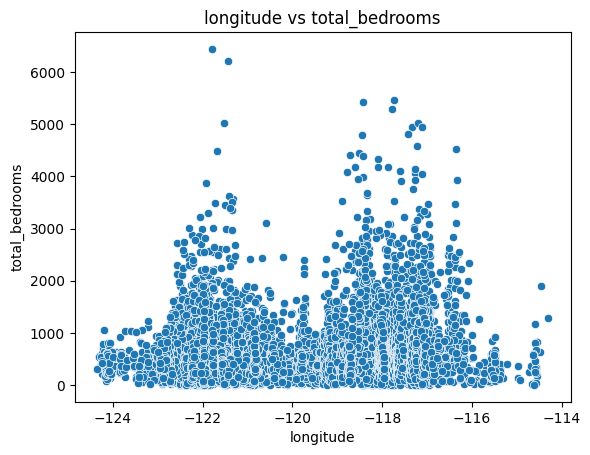

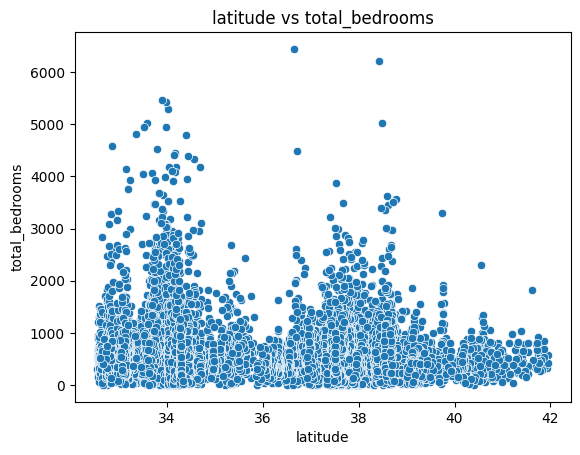

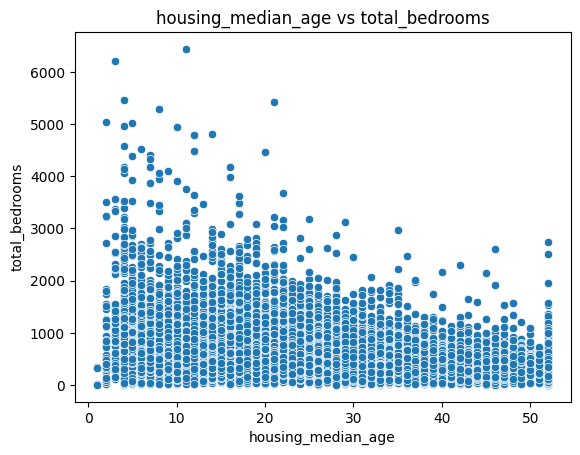

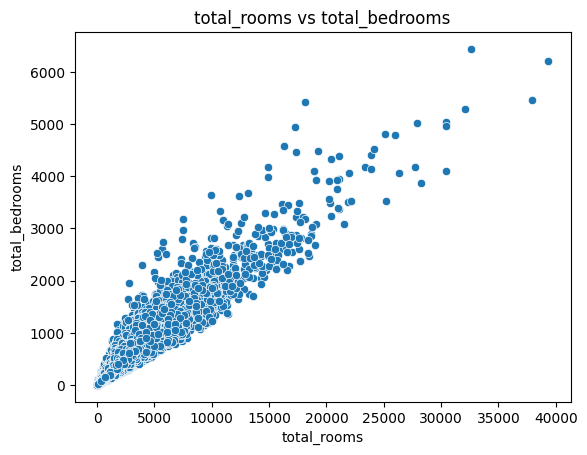

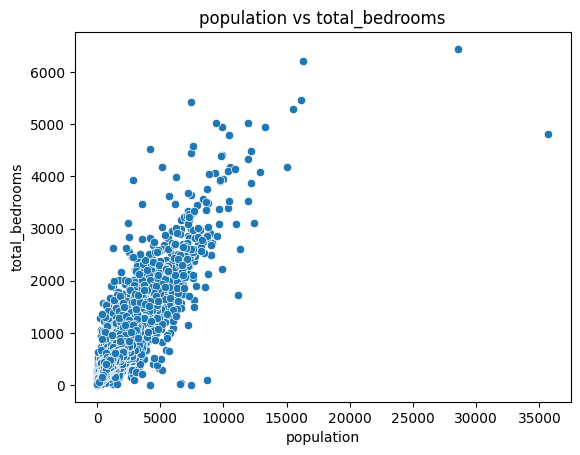

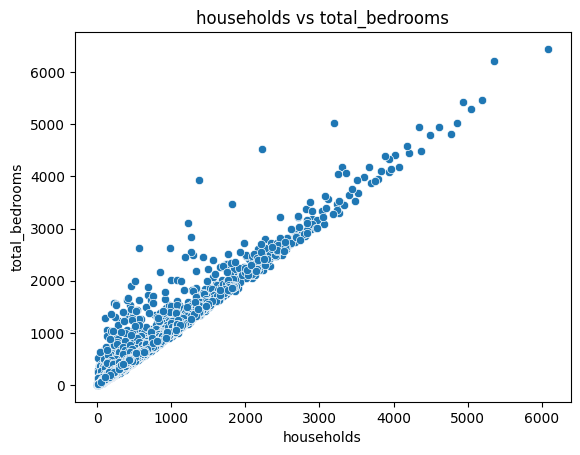

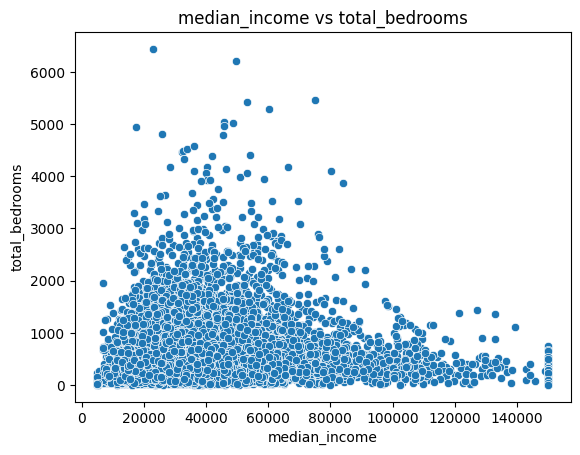

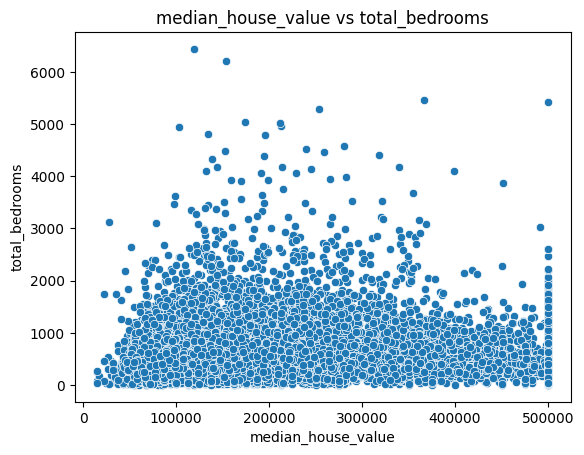

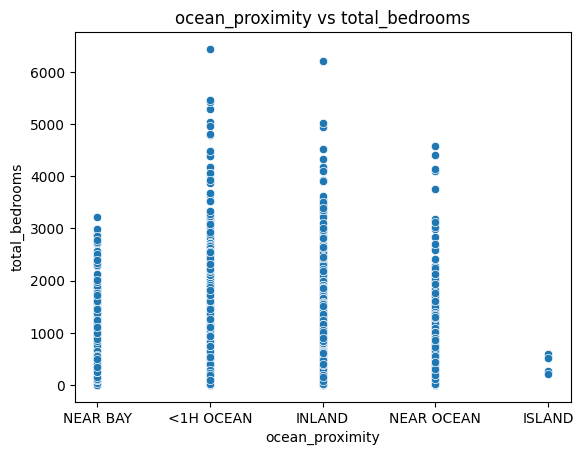

In [86]:
df2.corr(numeric_only=True)["total_bedrooms"]

for col in df2.columns:
    if col != "total_bedrooms":
        sns.scatterplot(x=df2[col], y=df2["total_bedrooms"] )
        plt.title(f"{col} vs total_bedrooms")
        plt.show()

It seems like total_bedrooms is heavily correlated with households , so we will do Linear Regression here

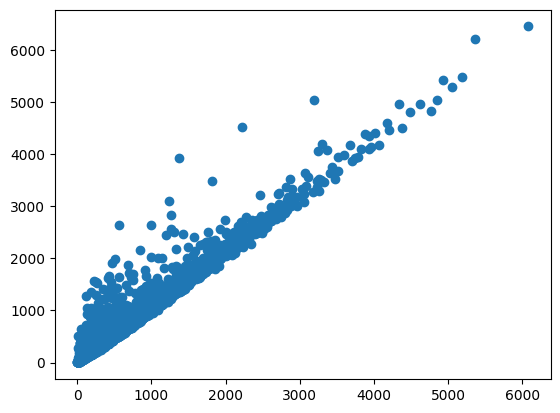

In [87]:
from numpy._core.fromnumeric import shape
array = df2[['households','total_bedrooms']].values
# reshape for scaler
X = array[:,0:1]
Y = array[:,1:]
plt.plot(X,Y,'o')

In [88]:
from sklearn.preprocessing import MinMaxScaler
# create scaler
scaler_X = MinMaxScaler()
scaler_Y = MinMaxScaler()

# scale
X_scaled = scaler_X.fit_transform(X)
Y_scaled = scaler_Y.fit_transform(Y)

In [89]:
# Split into train & test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y_scaled, test_size=0.2, random_state=556)

In [90]:
# convert back for model
y_train = y_train.ravel()

In [91]:
# Create model (Linear Regression using Gradient Descent)
model = SGDRegressor(loss = "huber",max_iter=1000, learning_rate='adaptive', eta0=0.5, alpha=0,verbose = 0,tol=0.001)

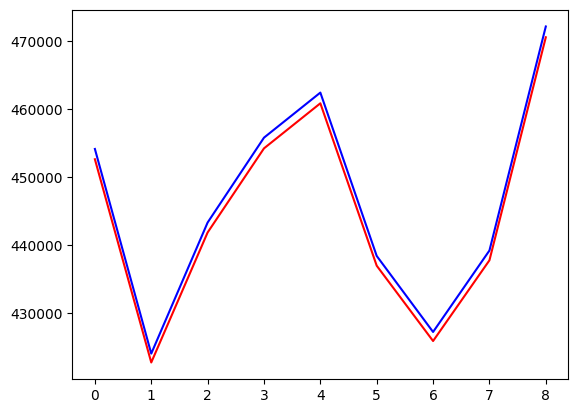

In [92]:
from sklearn.utils import shuffle
batch_size = 1486
epochs = 9
train_Loss = [] #store train cost function value for each epoch
test_Loss = []  #store test cost function value for each epoch
iterations = []

for epoch in range(epochs):
    X_train, y_train = shuffle(X_train, y_train)
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]

        model.partial_fit(X_batch, y_batch)


    y_test_pred = model.predict(X_test)
    y_test_pred = y_test_pred.reshape(-1, 1)
    y_test_pred = scaler_Y.inverse_transform(y_test_pred)

    mse_test = mean_squared_error(y_test, y_test_pred)
    test_Loss.append(mse_test) # append cost

    y_train_pred = model.predict(X_train)
    y_train_pred = y_train_pred.reshape(-1, 1)
    y_train_pred = scaler_Y.inverse_transform(y_train_pred)

    mse_train = mean_squared_error(y_train, y_train_pred)

    train_Loss.append(mse_train)
    iterations.append(epoch)


# Plot points show test and training data cost function values with each epoch , based on that we can decide how much we have to train the model
plt.plot(iterations,train_Loss, label='Training Loss', color='blue')
plt.plot(iterations,test_Loss, label='Testing Loss', color='red')
plt.show()


In [93]:
y_test_pred = y_test_pred.reshape(-1, 1)
y_test_pred = scaler_Y.inverse_transform(y_test_pred)
mse = mean_squared_error(y_test, y_test_pred)
print("MSE:", mse)
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)


MSE: 19547320961179.305
Coefficients: [1.02391873]
Intercept: [0.00090852]


In [94]:
# now fill the null values by our trained model

mask = df['total_bedrooms'].isnull()

tp = df.loc[mask, ['households']]   # shape (207, 1)
predicted_values = model.predict(tp)

df.loc[mask, 'total_bedrooms'] = predicted_values


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SGDRegressor was fitted without feature names
  warnings.warn(


# **Data filling ends here**

now the null values are filled and whole data is cleaned , we have to check for model prediction for our main column **median_house_value**

In [95]:
# it is observed that per_household values are more relevent and meaningful than the original ones

df["rooms_per_household"] = df["total_rooms"] / df["households"]
df["population_per_household"] = df["population"] / df["households"]
df["bedrooms_per_household"] = df["total_bedrooms"] / df["households"]

In [96]:
#ma = pd.get_dummies(df, columns=["ocean_proximity"],drop_first=True)
#print(ma)

In [97]:
df[['longitude', 'latitude','housing_median_age','households','median_income','bedrooms_per_household','rooms_per_household'
,'population_per_household','median_house_value']].corr(numeric_only=True)

# it is clear that median_house_value is significantly linearly correlated with median_income only

,longitude,latitude,housing_median_age,households,median_income,bedrooms_per_household,rooms_per_household,population_per_household,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.055310,-0.015176,0.013258,-0.027540,0.002476,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.071035,-0.079809,0.069775,0.106389,0.002366,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.302916,-0.119034,-0.077633,-0.153277,0.013191,0.105623
households,0.055310,-0.071035,-0.302916,1.000000,0.013033,-0.054913,-0.080598,-0.027309,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.013033,1.000000,-0.061922,0.326895,0.018766,0.688075
bedrooms_per_household,0.013258,0.069775,-0.077633,-0.054913,-0.061922,1.000000,0.847388,-0.006165,-0.046504
rooms_per_household,-0.027540,0.106389,-0.153277,-0.080598,0.326895,0.847388,1.000000,-0.004852,0.151948
population_per_household,0.002476,0.002366,0.013191,-0.027309,0.018766,-0.006165,-0.004852,1.000000,-0.023737
median_house_value,-0.045967,-0.144160,0.105623,0.065843,0.688075,-0.046504,0.151948,-0.023737,1.000000


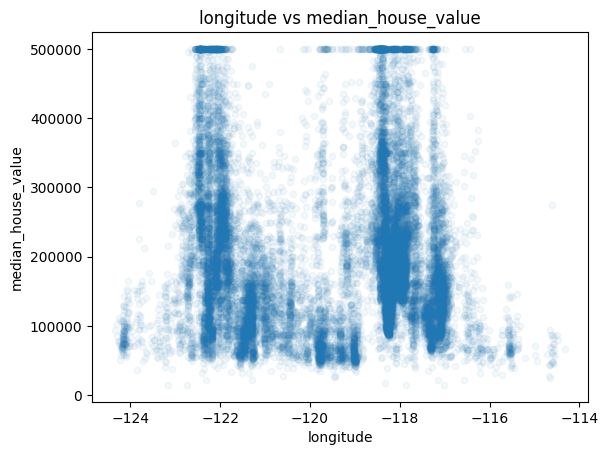

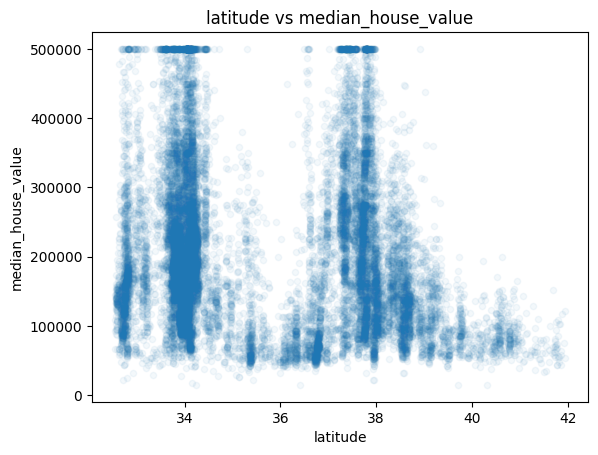

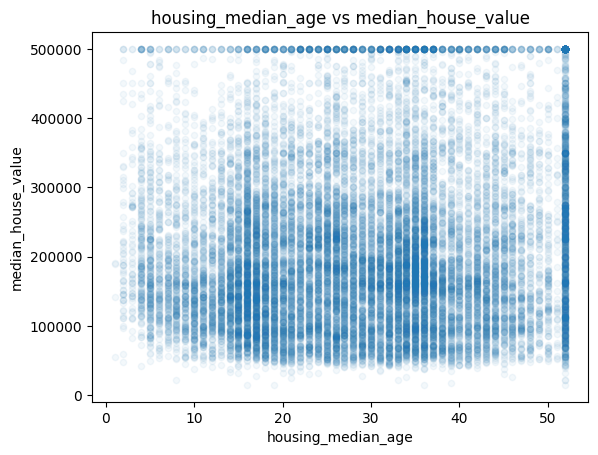

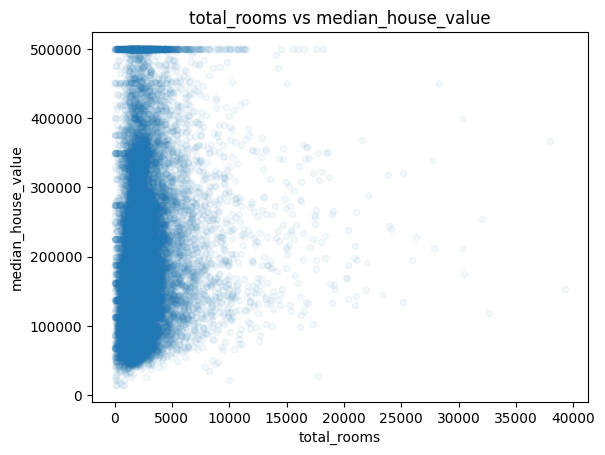

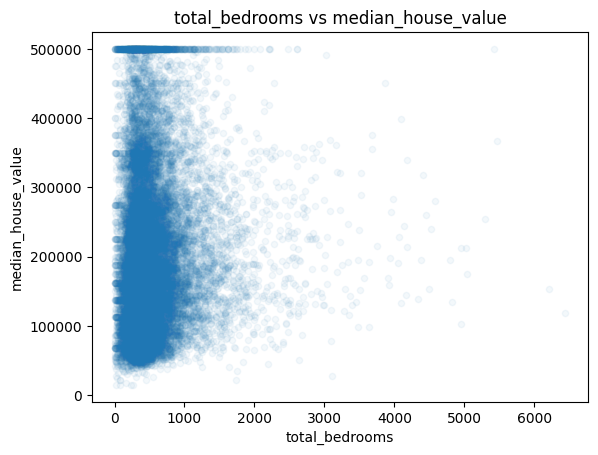

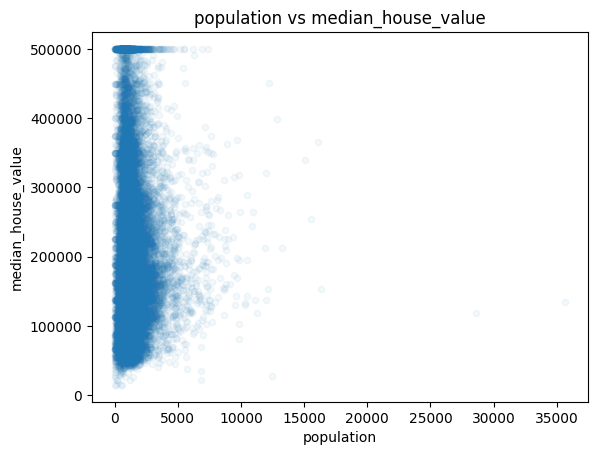

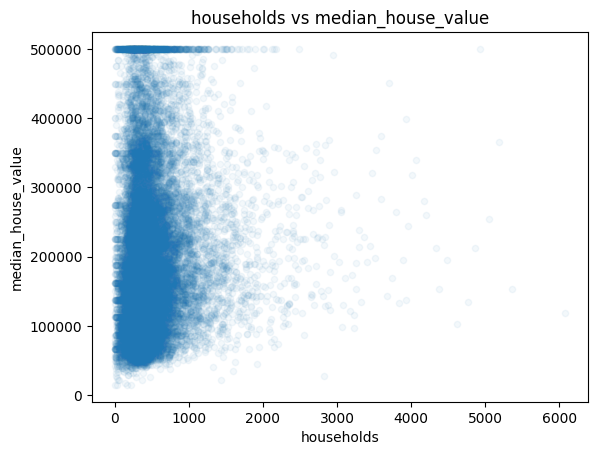

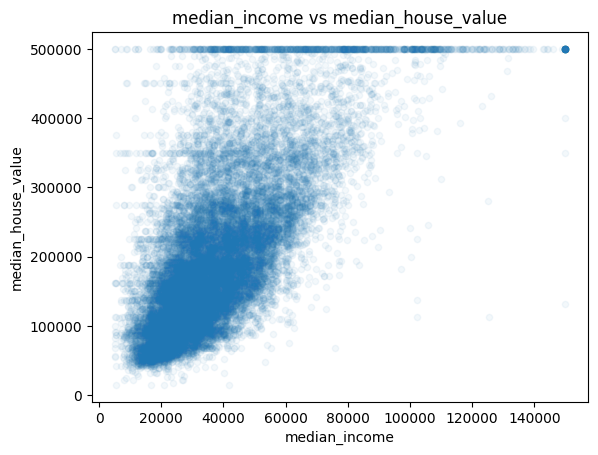

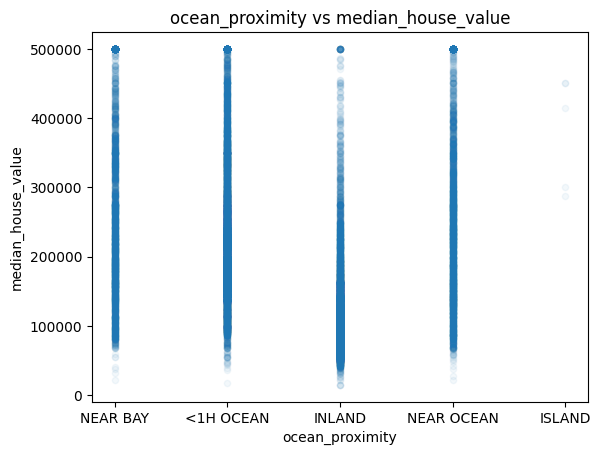

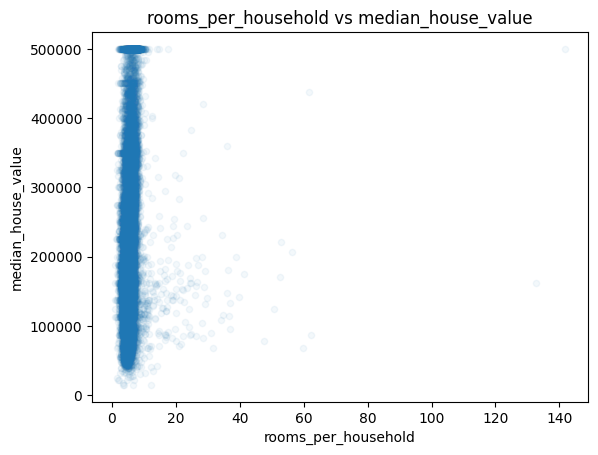

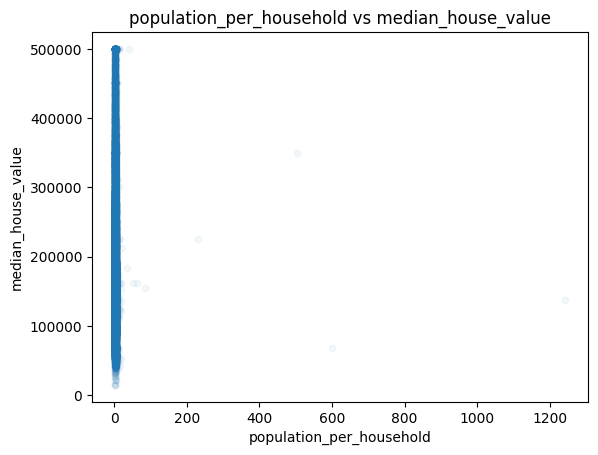

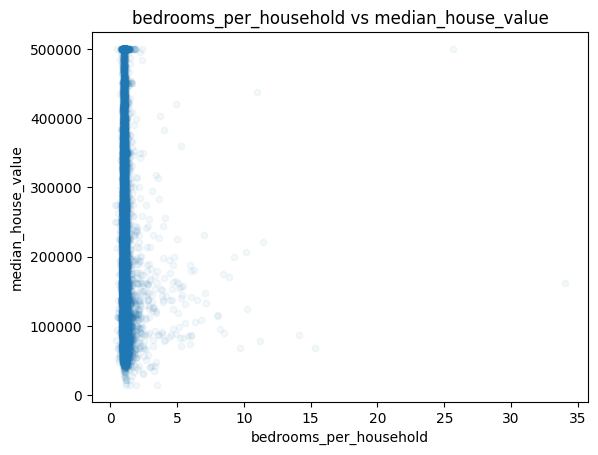

In [98]:

for col in df.columns:
    if col != "median_house_value":
        df.plot(kind="scatter", x=col, y="median_house_value", alpha=0.05)
        plt.title(f"{col} vs median_house_value")
        plt.show()

# The plot shows that median_house_value also shows some patterns with longitude and latitude

In [99]:
#categories = df["ocean_proximity"].unique()
'''price = [0 , 100000,200000,300000,400000,500002]
i=0

for i in range(len(price)-1):
    subset = df[(df["median_house_value"] >= price[i]) & (df["median_house_value"] < price[i+1]) ]

    label = f"{price[i]} - {price[i+1]}"

    plt.scatter(subset["longitude"], subset["latitude"], label = label , alpha = 1)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()'''

'price = [0 , 100000,200000,300000,400000,500002]\ni=0\n\nfor i in range(len(price)-1):\n    subset = df[(df["median_house_value"] >= price[i]) & (df["median_house_value"] < price[i+1]) ]\n\n    label = f"{price[i]} - {price[i+1]}"\n\n    plt.scatter(subset["longitude"], subset["latitude"], label = label , alpha = 1)\n\nplt.xlabel("Longitude")\nplt.ylabel("Latitude")\nplt.legend()\nplt.show()'

In [100]:
# divided longitude and latitude into some regions
df["latitude_division"] = None

df.loc[(df["latitude"] >= 32) & (df["latitude"] < 34.5), "latitude_division"] = 4
df.loc[(df["latitude"] >= 34.5) & (df["latitude"] < 36.55), "latitude_division"] = 3
df.loc[(df["latitude"] >= 36.55) & (df["latitude"] < 38.8), "latitude_division"] = 2
df.loc[(df["latitude"] >= 38.8) & (df["latitude"] < 43), "latitude_division"] = 1

df["longitude_division"] = None

df.loc[(df["longitude"] >= -127) & (df["longitude"] < -122.8), "longitude_division"] = 1
df.loc[(df["longitude"] >= -122.8) & (df["longitude"] < -121.8), "longitude_division"] = 2
df.loc[(df["longitude"] >= -121.8) & (df["longitude"] < -120), "longitude_division"] = 3
df.loc[(df["longitude"] >= -120) & (df["longitude"] < -117), "longitude_division"] = 4
df.loc[(df["longitude"] >= -117) & (df["longitude"] < -114), "longitude_division"] = 5

In [101]:
result = df.groupby(["latitude_division", "longitude_division"]).apply(
    lambda x: (x["median_house_value"] <= 220000).mean() * 100)

table = result.unstack()

print(table)
# Table shows percentage of points on each divided region that have median_income <=22000
# High percentage => poor areas
# NaN => no point(house in that range of longitude + latitude)

longitude_division          1          2          3          4           5
latitude_division                                                         
1                   99.307958  99.694190  96.786389  96.875000         NaN
2                   55.128205  38.485876  88.853647  98.540146         NaN
3                         NaN  16.666667  68.545994  97.315436  100.000000
4                         NaN        NaN   0.000000  58.103265   87.903226


/tmp/ipykernel_2032/1269753115.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby(["latitude_division", "longitude_division"]).apply(


In [102]:
result = df.groupby(["latitude_division", "longitude_division"])["median_house_value"].quantile(0.95)

table = result.unstack()

print(table)

longitude_division         1          2         3         4         5
latitude_division                                                    
1                   156220.0  139110.00  206360.0  205625.0       NaN
2                   295610.0  500001.00  269290.0  165330.0       NaN
3                        NaN  492000.75  346880.0  167835.0   87140.0
4                        NaN        NaN  425000.0  500001.0  273555.0


# **Testing Models**

Now we know that longitude , latitude and median_income are the three important columns here

In [103]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'rooms_per_household',
       'population_per_household', 'bedrooms_per_household',
       'latitude_division', 'longitude_division'],
      dtype='object')

In [104]:
#df = pd.get_dummies(df, columns=['ocean_proximity'], drop_first=False)

In [105]:
# we can experiment different the combinations to check weightage of features

lst1 = ['longitude', 'latitude','housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
        'rooms_per_household',
       'population_per_household', 'bedrooms_per_household'
        ]

lst2 = ['housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
        'rooms_per_household',
       'population_per_household', 'bedrooms_per_household']

lst3 = ['longitude', 'latitude', 'housing_median_age', 'households', 'median_income',
        'rooms_per_household',
       'population_per_household', 'bedrooms_per_household']

lst4 =  ['housing_median_age', 'households', 'median_income',
        'rooms_per_household',
       'population_per_household', 'bedrooms_per_household']

lst = [lst1,lst2,lst3,lst4]

Linear Regression

```
# This is formatted as code
```



In [106]:
import copy

def find_answer(features , df , answer):

  model = SGDRegressor(loss = "squared_error", max_iter=1000, learning_rate='adaptive', eta0=0.01, alpha=0,verbose = 0,tol=0.001,random_state=None)
  X = df[features].values
  Y = df[[answer]].values
  #create scaler
  scaler_X = MinMaxScaler()
  scaler_Y = MinMaxScaler()

  # scale
  X_scaled = scaler_X.fit_transform(X)
  Y_scaled = scaler_Y.fit_transform(Y)

  # Split into train & test
  X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y_scaled, test_size=0.2, random_state=None)

  # convert back for model
  y_train = y_train.ravel()

  epochs = 10
  batch_size = 1008

  for epoch in range(epochs):
    X_train, y_train = shuffle(X_train, y_train)
    #print("***************epoch************* : ",epoch +1 )
    for i in range(0, len(X_train), batch_size):
        X_batch = X_train[i:i+batch_size]
        y_batch = y_train[i:i+batch_size]
        model.partial_fit(X_batch, y_batch)

  #model.fit(X_train, y_train)

  y_test_pred = model.predict(X_test)
  y_test_pred = y_test_pred.reshape(-1, 1)
  y_test_pred = scaler_Y.inverse_transform(y_test_pred)
  y_test = scaler_Y.inverse_transform(y_test)

  mse_test = mean_squared_error(y_test, y_test_pred)

  '''
  # Also show plot

  plt.figure(figsize=(10,6))
  plt.scatter(y_test, y_test_pred, alpha=0.5)
  plt.xlabel("Actual Values")
  plt.ylabel("Predicted Values")
  plt.title("Actual vs Predicted House Prices")

  '''
  plt.show()

  return mse_test

  #y_train_pred = model.predict(X_train)
  #y_train_pred = y_train_pred.reshape(-1, 1)
  #y_train_pred = scaler_Y.inverse_transform(y_train_pred)
  #mse_train = mean_squared_error(y_train, y_train_pred)




for i in lst:
    #copied_list = lst1.copy()
    #copied_list.remove(i)

    print(find_answer(i , df , 'median_house_value' ) )


5105068510.362742
6272772400.163851
4900651917.762763
6161203962.030741


**XGBoostRegressor**

In [107]:
!pip install xgboost
!pip install --upgrade xgboost

In [108]:
from xgboost import XGBRegressor

def find_answer_xgb(features, df, answer):

    X = df[features]
    y = df[answer]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=556)

    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)

    return mse, model


for features in lst:
    mse, model = find_answer_xgb(features, df, 'median_house_value')
    print(mse )

2262898379.3969965
3973864246.686284
2206213185.755106
3956782315.8857903


LightGBMRegressor

In [109]:
from lightgbm import LGBMRegressor

def find_answer_lgbm(features, df, answer):

    X = df[features]
    y = df[answer]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=556)

    model = LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=-1,
        random_state=42)

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    '''
    plt.figure(figsize=(10,6))
    plt.scatter(y_test, y_pred, alpha=0.5)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title("Actual vs Predicted House Prices")
    plt.show()
    '''

    mse = mean_squared_error(y_test, y_pred)

    return mse, model




for features in lst:
    mse, model = find_answer_lgbm(features, df, 'median_house_value')
    print(mse)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.010526 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2603
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 11
[LightGBM] [Info] Start training from score 206908.319404
2201272489.6288795
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001468 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2093
[LightGBM] [Info] Number of data points in the train set: 16512, number of used features: 9
[LightGBM] [Info] Start training from score 206908.319404
3924667941.208497
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001322 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1838
[LightGBM] [Info] Number of data points in the train set: 16512, number of

RandomForestRegressor

In [110]:
from sklearn.ensemble import RandomForestRegressor

def find_answer_rf(features, df, answer):

    X = df[features]
    y = df[answer]

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=556
    )

    # Model
    model = RandomForestRegressor(
        n_estimators=100,     # reduce trees
        max_depth=None,        # limit depth
        random_state=None,
        n_jobs=-1)

    # Train
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)

    # MSE
    mse = mean_squared_error(y_test, y_pred)

    return mse, model



for features in lst:
    mse, model = find_answer_rf(features, df, 'median_house_value')
    print(mse)

2571052371.93648
4099210712.892665
2537657075.297319
4110973210.7004066


LightGBM is showing least error , hence it is performing best here